# 3_angry_mob
ensemble testing a set of pitchfork networks
ToDo:
- Plots of different solar tracks at low alpha plotted over true track
- Plots of distributions of output predictions for different points
- Plots of standard deviation of uncertainty distributions as a function of N

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-03-01 10:57:40.285705: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-01 10:57:40.285734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-01 10:57:40.286576: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-03-01 10:57:40.291211: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-01 10:57:40.848911: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-03-01 10:57:41.341663: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1016 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [3]:
#### path definition
path = Path(os.getcwd())
path = path.relative_to(*path.parts[:4])

#### load in grid
#df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/' + str(path) + '/data/df_all_log.h5', key='df')
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/df_all_log.h5', key='df')

#### normalise/standardise
for column in df_full.columns:
    df_full[column+"_std"] = (df_full[column]-df_full[column].mean())/df_full[column].std()

#df_full.describe()

#### define inputs
inputs = ['initial_mass_std', 'initial_Zinit_std', 'initial_Yinit_std', 'initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'star_feh_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.995, random_state=seed)
df_test = df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Testing set: ", len(df_test))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  2424255
Testing set:  12243
Validation set:  12183


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
count,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,...,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06
mean,1.021885e+00,1.440698e-02,2.814693e-01,2.117984e+00,5.000177e+00,1.312728e+00,2.116482e+00,5.870890e+03,-1.127145e-01,5.459277e+02,...,5.100371e-15,3.629539e-15,2.700240e-15,1.435547e-15,-4.423639e-15,8.003407e-15,-8.417543e-15,1.289578e-15,-3.185318e-15,3.670395e-15
std,1.175610e-01,9.677123e-03,2.805593e-02,2.879175e-01,3.405371e+00,4.813547e-01,1.572419e+00,5.674285e+02,3.499532e-01,2.021373e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,8.000000e-01,3.869061e-03,2.400000e-01,1.700000e+00,2.966411e-02,6.990236e-01,1.321735e-01,4.099787e+03,-1.077903e+00,1.545097e+02,...,-2.605045e+00,-2.599363e+00,-2.594960e+00,-2.591708e+00,-2.589646e+00,-2.588901e+00,-2.589287e+00,-2.590747e+00,-2.593002e+00,-2.595848e+00
25%,9.200000e-01,6.471429e-03,2.600000e-01,1.900000e+00,2.309880e+00,9.719693e-01,9.371542e-01,5.495672e+03,-4.000000e-01,3.986516e+02,...,-5.612334e-01,-5.643108e-01,-5.676179e-01,-5.705508e-01,-5.723483e-01,-5.730070e-01,-5.725672e-01,-5.713737e-01,-5.700038e-01,-5.685747e-01
50%,1.040000e+00,1.077191e-02,2.800000e-01,2.100000e+00,4.275231e+00,1.160016e+00,1.698469e+00,5.863863e+03,-1.000000e-01,5.591040e+02,...,2.414913e-01,2.417789e-01,2.415099e-01,2.405877e-01,2.389688e-01,2.369176e-01,2.348740e-01,2.333131e-01,2.326247e-01,2.327753e-01
75%,1.120000e+00,2.007835e-02,3.000000e-01,2.300000e+00,7.159688e+00,1.498369e+00,2.883064e+00,6.223793e+03,1.837200e-01,6.947397e+02,...,7.562359e-01,7.569644e-01,7.578097e-01,7.587334e-01,7.595544e-01,7.599729e-01,7.598420e-01,7.591873e-01,7.580180e-01,7.566985e-01
max,1.200000e+00,3.897971e-02,3.200000e-01,2.500000e+00,1.399997e+01,2.873431e+00,1.163902e+01,7.998610e+03,5.094573e-01,1.021990e+03,...,1.616724e+00,1.617024e+00,1.618137e+00,1.620054e+00,1.622624e+00,1.625764e+00,1.629202e+00,1.632519e+00,1.633559e+00,1.635647e+00


In [3]:
"""
pca
"""
#### define pca global vars
n_components = 4
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 4 is 0.999999896009264


In [4]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()

unlog_weights = [0.1] / df_full['star_feh'].std()

weights = log_weights.values[[0,1]].tolist() + unlog_weights.tolist() + log_weights.values[2:].tolist()

print(weights)

[0.02324560601067967, 0.012220076304794422, 0.2857524907848119, 0.00012220154533326764, 0.00011530706805035573, 0.000109209187475727, 0.00010373957827574545, 9.877493746324607e-05, 9.424043658607474e-05, 9.008674371702482e-05, 8.626668769588676e-05, 8.273438289926203e-05, 7.944721575439512e-05, 7.636537366843286e-05]


In [5]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

## Calculating error function for angry mob


In [7]:
"""
load in angry mob
"""
pca_comps = pca.components_
pca_mean = pca.mean_

custom_objects = {"InversePCA": InversePCA(pca_comps, pca_mean),"WMSE": WMSE(weights)}

angry_mob = {}

for i in range(279):
    pitchfork_name = "pitchfork_"+str(i)
    print("loaded in pitchfork " + str(i), end="\r")
    angry_mob[pitchfork_name] = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/" + str(path) + "/models/angry_mob_1/" + pitchfork_name + ".h5", custom_objects=custom_objects)


In [8]:
i = 99
inputs = ['initial_mass_std', 'initial_Zinit_std', 'initial_Yinit_std', 'initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'star_feh_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = ['radius', 'luminosity', 'star_feh'] + [f'nu_0_{i+1}' for i in range(14,25)]

pitchfork_name = "pitchfork_"+str(i)

pcann_model = angry_mob[pitchfork_name]

preds = pcann_model(np.array(df_test[inputs]))

preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)


for output in outputs:
    preds_df[output] = rescale_preds(preds_df, df_full, output)

preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

pitchfork_errors_df=pd.DataFrame(np.array(df_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

2024-02-19 13:41:39.816504: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-19 13:41:39.873745: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


In [9]:
"""
solar like test point, expand to more later
"""

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit[df_mass_zinit["star_age"] == df_mass_zinit.iloc[(df_mass_zinit['star_age']-4.6).abs().argsort()[:1]]['star_age'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit_sol.set_index(np.arange(0,len(df_mass_zinit_sol)))
df_mass_zinit_sol

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
0,1.0,0.01351,0.24,1.7,4.60741,1.01415,0.900577,5587.384436,-0.059509,664.159571,...,0.66122,0.662344,0.66362,0.664468,0.664161,0.664774,0.664463,0.663024,0.660595,0.658428


In [4]:
"""
FOR SKILLS SESSION
"""

# extract solar track:
df_mass = df_full[df_full["initial_mass"]==1.0]

df_mass_zinit = df_mass[df_mass["initial_Zinit"] == df_mass.iloc[(df_mass['initial_Zinit']-0.014).abs().argsort()[:1]]['initial_Zinit'].tolist()[0]]
df_mass_zinit_sol = df_mass_zinit.set_index(np.arange(0,len(df_mass_zinit)))
df_mass_zinit_sol

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
0,1.0,0.01351,0.24,1.7,0.156093,0.903762,0.668757,5494.389081,-0.001713,777.657940,...,1.029481,1.030415,1.031858,1.033766,1.036062,1.038559,1.040632,1.041104,1.042363,1.042442
1,1.0,0.01351,0.24,1.7,0.179775,0.904673,0.670444,5495.082833,-0.002029,776.560078,...,1.026254,1.027191,1.028635,1.030541,1.032830,1.035316,1.037344,1.037826,1.039056,1.039100
2,1.0,0.01351,0.24,1.7,0.208193,0.905639,0.672218,5495.781679,-0.002407,775.397642,...,1.022835,1.023776,1.025221,1.027125,1.029407,1.031880,1.033857,1.034353,1.035552,1.035559
3,1.0,0.01351,0.24,1.7,0.242295,0.906681,0.674140,5496.544196,-0.002859,774.146867,...,1.019153,1.020097,1.021544,1.023445,1.025720,1.028179,1.030096,1.030612,1.031776,1.031743
4,1.0,0.01351,0.24,1.7,0.283217,0.907821,0.676270,5497.425306,-0.003399,772.782215,...,1.015129,1.016077,1.017524,1.019424,1.021691,1.024133,1.025977,1.026522,1.027649,1.027570
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,1.0,0.01351,0.24,1.7,12.974752,2.560618,2.860885,4694.422351,-0.011818,172.077218,...,-2.358404,-2.354174,-2.350755,-2.348180,-2.346648,-2.346083,-2.346540,-2.347941,-2.350141,-2.352846
479,1.0,0.01351,0.24,1.7,12.979438,2.574392,2.887623,4692.747362,-0.011516,170.697019,...,-2.376173,-2.371892,-2.368439,-2.365848,-2.364313,-2.363789,-2.364315,-2.365799,-2.368095,-2.370864
480,1.0,0.01351,0.24,1.7,12.984075,2.588302,2.914764,4691.079452,-0.011268,169.218582,...,-2.393963,-2.389691,-2.386256,-2.383675,-2.382125,-2.381601,-2.382140,-2.383665,-2.386037,-2.388886
481,1.0,0.01351,0.24,1.7,12.988658,2.602206,2.942176,4689.490859,-0.011023,167.823038,...,-2.411661,-2.407358,-2.403916,-2.401352,-2.399818,-2.399338,-2.399929,-2.401512,-2.403949,-2.406852


In [6]:
nn_session_df = df_mass_zinit_sol[['star_age', 'luminosity', 'effective_T']]
nn_session_df

,star_age,luminosity,effective_T
0,0.156093,0.668757,5494.389081
1,0.179775,0.670444,5495.082833
2,0.208193,0.672218,5495.781679
3,0.242295,0.674140,5496.544196
4,0.283217,0.676270,5497.425306
...,...,...,...
478,12.974752,2.860885,4694.422351
479,12.979438,2.887623,4692.747362
480,12.984075,2.914764,4691.079452
481,12.988658,2.942176,4689.490859


In [10]:
nn_session_df.to_csv('solar_track.csv', index=False)

In [11]:
nn_session_csv_test = pd.read_csv('solar_track.csv')

In [12]:
nn_session_csv_test

,star_age,luminosity,effective_T
0,0.156093,0.668757,5494.389081
1,0.179775,0.670444,5495.082833
2,0.208193,0.672218,5495.781679
3,0.242295,0.674140,5496.544196
4,0.283217,0.676270,5497.425306
...,...,...,...
478,12.974752,2.860885,4694.422351
479,12.979438,2.887623,4692.747362
480,12.984075,2.914764,4691.079452
481,12.988658,2.942176,4689.490859


In [10]:
random_point = df_test.sample(1)
random_point

,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
3852602,1.0,0.006472,0.28,2.5,6.755134,1.912508,4.006638,5909.119252,-0.352249,274.31737,...,-1.394733,-1.392238,-1.389507,-1.386734,-1.384351,-1.382329,-1.380742,-1.379581,-1.379028,-1.378796


In [11]:
"""
generate empty dataframe for population later
"""
outputs_T = ['radius', 'luminosity', 'star_feh'] + [f'nu_0_{i+1}' for i in range(14,25)] + ['effective_T']

angry_mob_error_cols = ['N']

for output in outputs_T:
    angry_mob_error_cols.append(output+'_std')
    angry_mob_error_cols.append(output+'_mean')
    angry_mob_error_cols.append(output+'_z')

"""
populate dataframe with error by N
"""

inputs = ['initial_mass_std', 'initial_Zinit_std', 'initial_Yinit_std', 'initial_MLT_std', 'log_star_age_std']

pred_outputs = ['log_radius_std', 'log_luminosity_std', 'star_feh_std'] + [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = ['radius', 'luminosity', 'star_feh'] + [f'nu_0_{i+1}' for i in range(14,25)]

df_to_test = df_mass_zinit_sol

errors_dict = {}
for n in range(279):
    pitchfork_name = "pitchfork_"+str(n)

    
    pitchfork = angry_mob[pitchfork_name]
    
    preds = pitchfork(np.array(df_to_test[inputs]))

    preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)

    for output in outputs:
        preds_df[output] = rescale_preds(preds_df, df_full, output)
    
    preds_df['effective_T'] = calc_Teff(preds_df["luminosity"],preds_df["radius"])

    errors_dict[pitchfork_name]=np.array(df_to_test[outputs+['effective_T']]) - np.array(preds_df[outputs+['effective_T']])
    print(pitchfork_name + " done", end="\r")
    #errors_dict[pitchfork_name]=np.array(preds_df[outputs+['effective_T']])


In [14]:
angry_mob_error_arr = []
rng = default_rng(seed=42)

for N in range(1,280):
    print("current N = " + str(N), end='\r')
    ### sample pitchforks according to N
    pitchfork_ids = rng.choice([n for n in range(279)], size=N, replace=False).tolist()

    i=0
    for pitchfork_id in pitchfork_ids:
        if i == 0:
            errors_df = pd.DataFrame(errors_dict["pitchfork_"+str(pitchfork_id)], columns = outputs+['effective_T'])
            i=1
        else:
            errors_df = pd.concat((errors_df, pd.DataFrame(errors_dict["pitchfork_"+str(pitchfork_id)], columns = outputs+['effective_T'])), ignore_index=True)
        
    angry_mob_error_N = [N]
    for output in errors_df.columns:
        errors_output = errors_df[output]
        error_std = errors_output.std()
        angry_mob_error_N.append(error_std)
        error_mean = errors_output.mean()
        angry_mob_error_N.append(error_mean)
        #error_z = (df_to_test[output].values - errors_output) / error_std
        error_z = errors_output / error_std
        angry_mob_error_N.append(error_z.values.tolist())

    
    angry_mob_error_arr.append(angry_mob_error_N)

angry_mob_error = pd.DataFrame(angry_mob_error_arr, columns = angry_mob_error_cols)

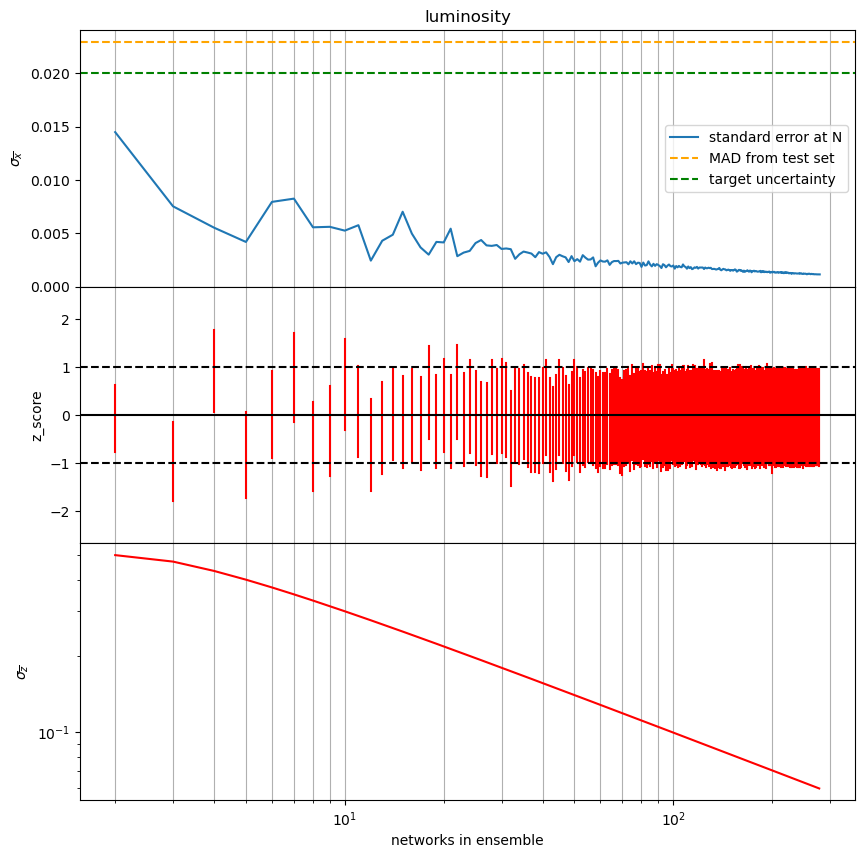

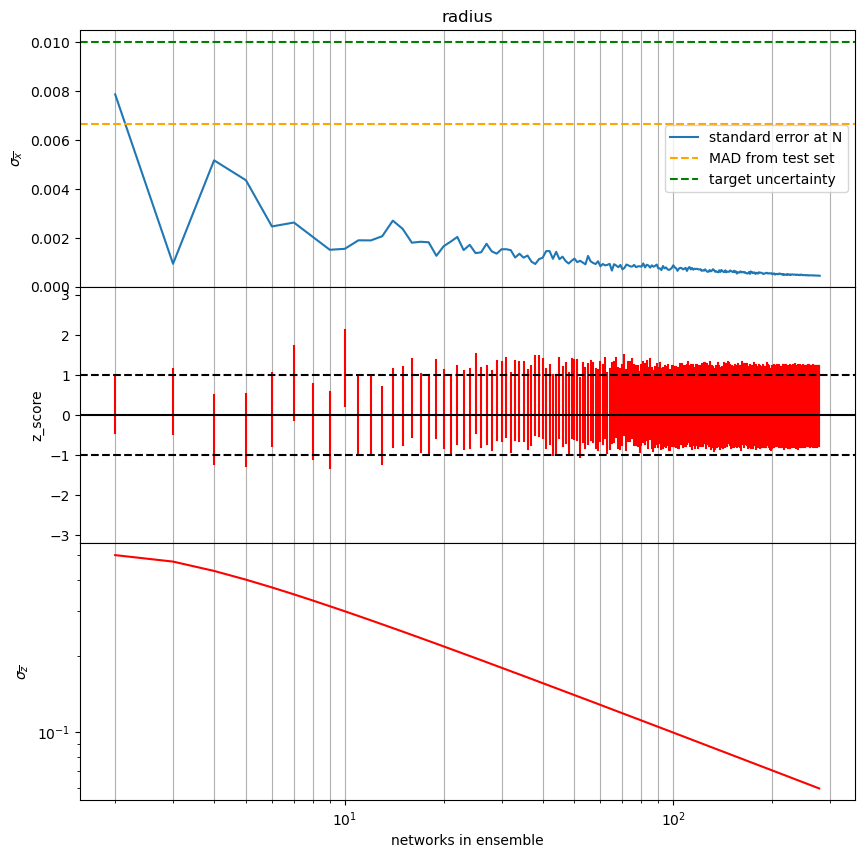

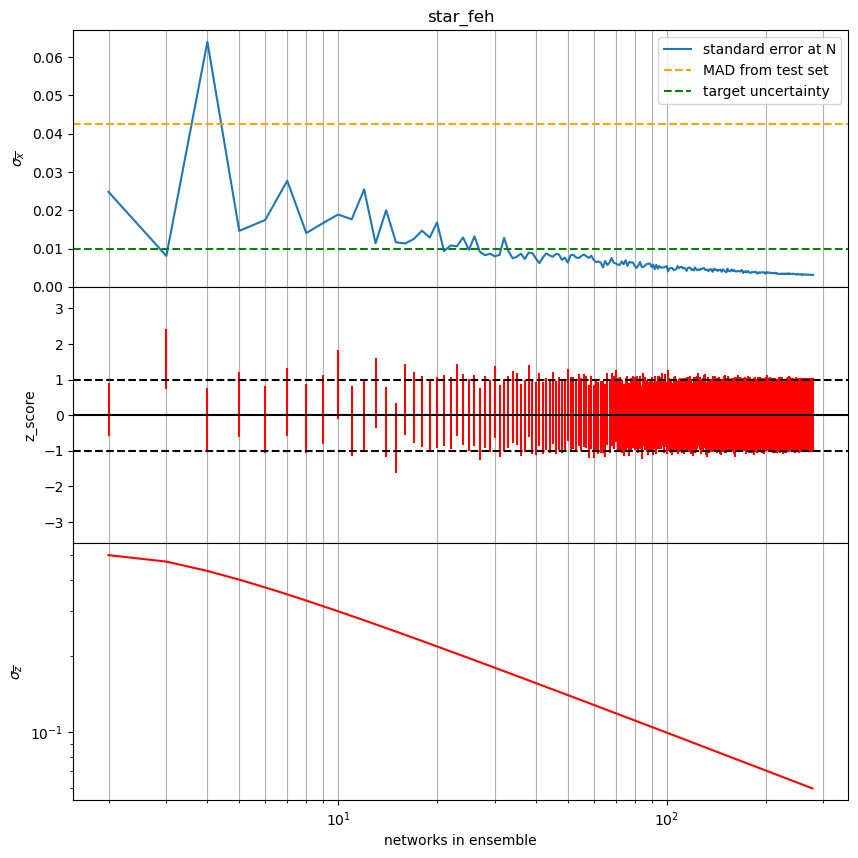

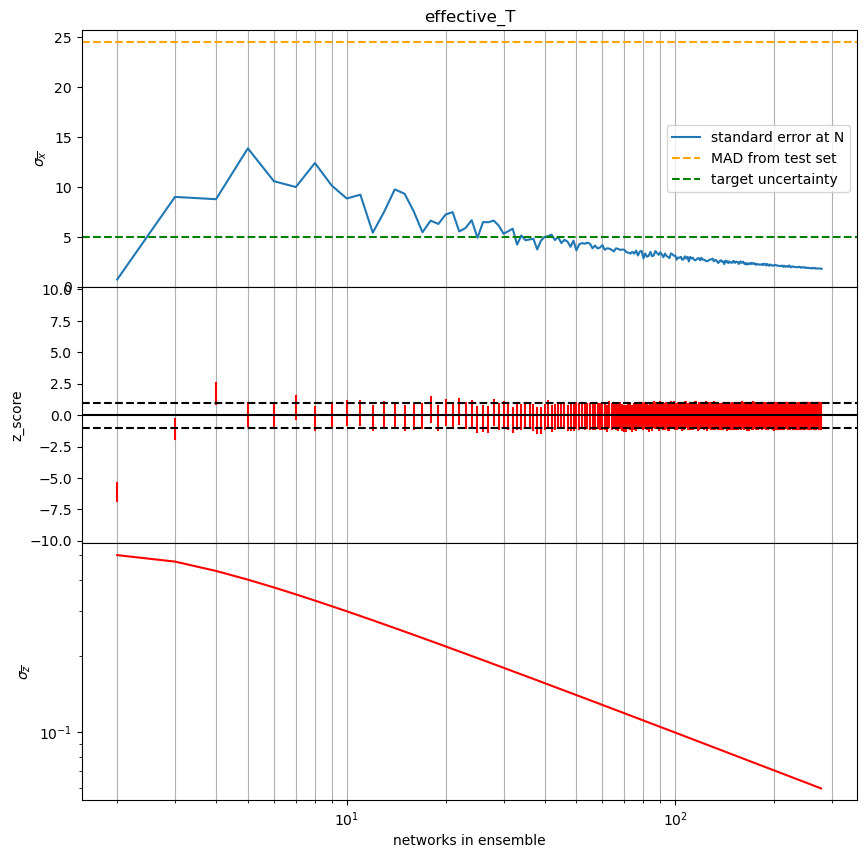

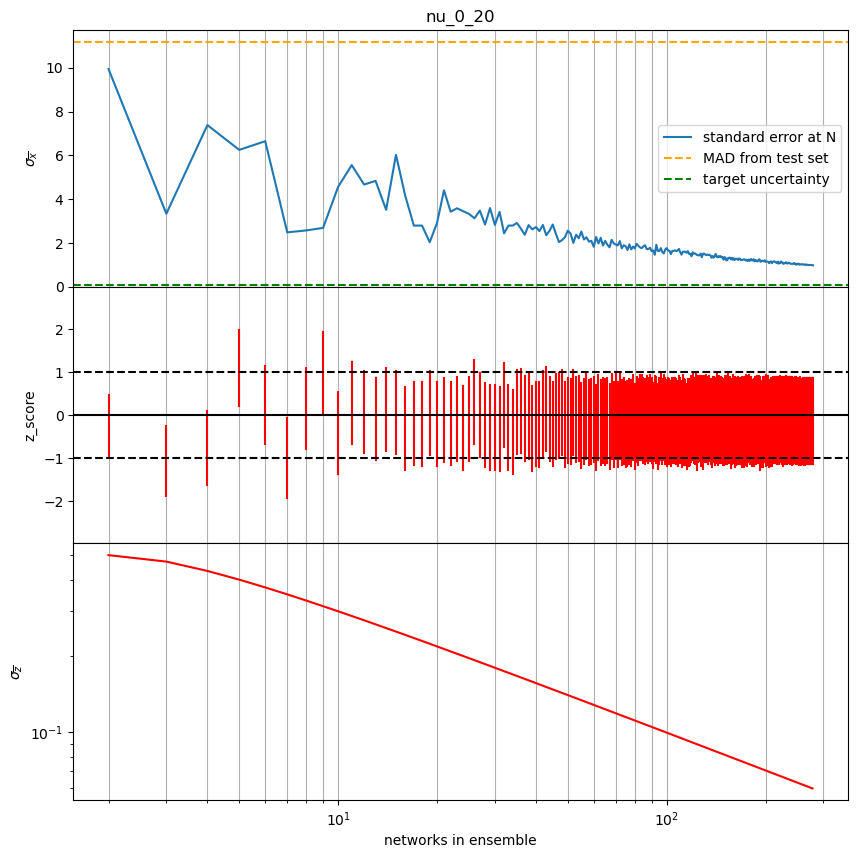

In [15]:
def plot_error_func(output, N):
    
    fig, (ax1, ax2, ax3) = plt.subplots(3,1,figsize=(10,10), dpi=100, sharex=True)
    plt.subplots_adjust(hspace=0)
    
    ax1.plot(angry_mob_error['N'], angry_mob_error[output+'_std']/np.sqrt(angry_mob_error['N']), label='standard error at N')
    ax1.axhline(stats.median_abs_deviation(pitchfork_errors_df[output]),linestyle='dashed', color='orange',label='MAD from test set')
    if output == "effective_T":
        ax1.axhline(5,linestyle='dashed', color='green',label='target uncertainty')
    elif output == "radius":
        ax1.axhline(0.01,linestyle='dashed', color='green',label='target uncertainty')
    elif output == "star_feh":
        ax1.axhline(0.01,linestyle='dashed', color='green',label='target uncertainty')
    elif output == "luminosity":
        ax1.axhline(0.02,linestyle='dashed', color='green',label='target uncertainty')
    else:
        ax1.axhline(0.1,linestyle='dashed', color='green',label='target uncertainty')

    
    ax1.legend()
    ax1.set_ylabel("$\sigma_\overline{x}$")
    ax1.set_title(output)
    ax1.set_xscale('log')
    ax1.set_ylim(0)
    ax1.set_xticklabels([])
    ax1.grid(which='both', axis='x')

    z_error_on_mean_arr=[]
    ylim_max = 0
    for n in range(N-1):
        z_vals = angry_mob_error[output+'_z'][n]
        z_std = np.std(z_vals)
        z_mean = np.mean(z_vals)
        z_error_on_mean_arr.append(z_std/np.sqrt(len(z_vals)))

        array = [z_mean-z_std,z_mean+z_std]
        check_ylim_max = max(np.abs(array))
        if check_ylim_max > ylim_max:
            ylim_max = check_ylim_max
        
        ax2.plot(np.full(2, n+1), array, color='red')
        
    ax2.axhline(-1, linestyle='dashed', color='black')
    ax2.axhline(0, color='black')
    ax2.axhline(1, linestyle='dashed', color='black')
    ax2.set_ylabel("z_score")
    ax2.set_xscale('log')
    ylim_max = ylim_max*1.5
    ax2.set_ylim(-ylim_max, ylim_max)
    ax2.set_xticklabels([])
    ax2.grid(which='both', axis='x')

    ax3.plot([n+1 for n in range(N-1)], z_error_on_mean_arr, color='red')
    ax3.set_ylabel("$\sigma_\overline{z}$")
    ax3.set_xlabel("networks in ensemble")
    ax3.set_yscale('log')
    ax3.set_xscale('log')
    ax3.grid(which='both', axis='x')
    
plot_error_func('luminosity', 279)
plot_error_func('radius', 279)
plot_error_func('star_feh', 279)
plot_error_func('effective_T', 279)
plot_error_func('nu_0_20', 279)